In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from statsmodels.tsa.seasonal import STL

In [3]:
df = pd.read_csv('product_usage_data.csv')

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [11]:
df.head()

,timestamp,daily_active_users
0,2024-01-01,1107
1,2024-01-02,1113
2,2024-01-03,1143
3,2024-01-04,1140
4,2024-01-05,1136


In [13]:
df.tail()

,timestamp,daily_active_users
86,2024-03-27,1135
87,2024-03-28,1130
88,2024-03-29,1108
89,2024-03-30,1113
90,2024-03-31,1103


In [17]:
z = (df['daily_active_users'] - df['daily_active_users'].mean()) / df['daily_active_users'].std()
df['z_anomaly'] = abs(z) > 2

In [19]:
Q1 = df['daily_active_users'].quantile(0.25)
Q3 = df['daily_active_users'].quantile(0.75)
IQR = Q3 - Q1
df['iqr_anomaly'] = (df['daily_active_users'] < Q1 - 1.5 * IQR) | (df['daily_active_users'] > Q3 + 1.5 * IQR)

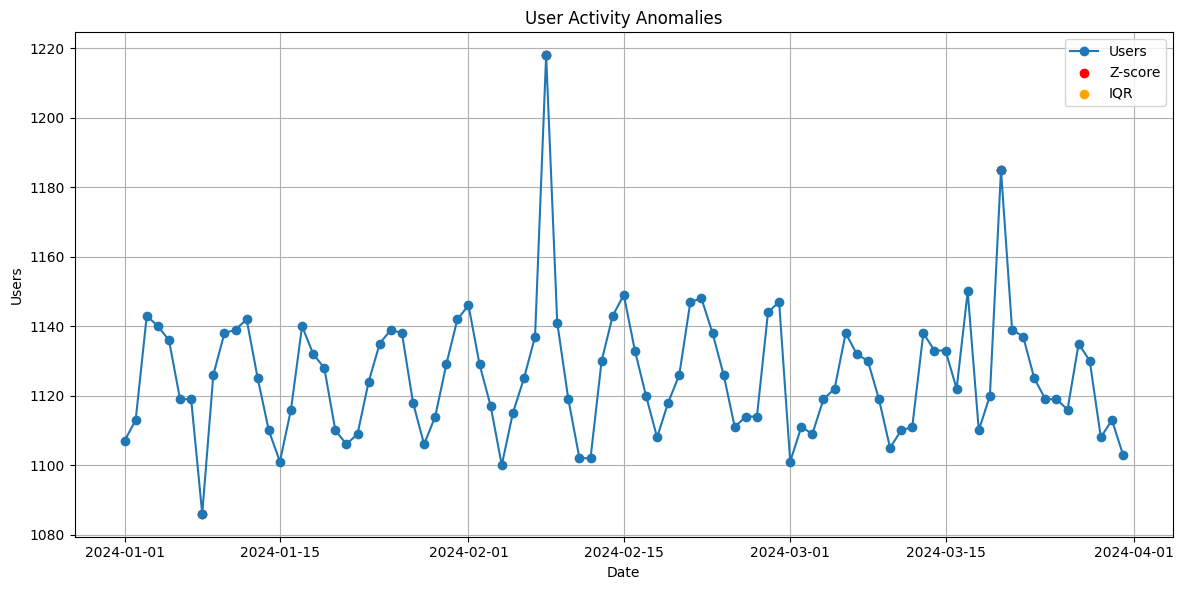

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['daily_active_users'], label='Users', marker='o')
plt.scatter(df[df['z_anomaly']]['timestamp'], df[df['z_anomaly']]['daily_active_users'], color='red', label='Z-score')
plt.scatter(df[df['iqr_anomaly']]['timestamp'], df[df['iqr_anomaly']]['daily_active_users'], color='orange', label='IQR')
plt.xlabel('Date')
plt.ylabel('Users')
plt.title('User Activity Anomalies')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()